### Support Vector Machines (SVM)

SVM is a powerful supervised learning algorithm used for classification (SVC) and regression (SVR) tasks. It is also used for outlier detection. ( Mostly for Classification ). It works by finding the optimal hyperplane that separates data points of different classes in a high-dimensional space.

Kernel is a function that transforms the data into a higher-dimensional space, allowing SVM to find a linear separation between classes that may not be linearly separable in the original feature space. Common kernels include linear, polynomial, and radial basis function (RBF).

- LinearSVC and SVC with Linear Kernel seperate on the basis of a straight line

- SVC with RBF Kernel can separate on the basis of a curve. It is more flexible than linear kernel but also more computationally expensive.

- SVC with polynomial kernel can separate on the basis of a polynomial curve. It is also more flexible than linear kernel but can be computationally expensive.

-In a Support Vector Machine:
- Without kernel: 
You find a linear hyperplane.

With kernel (like RBF or polynomial):
- You behave as if data lives in higher dimension.
- A linear separator there becomes a nonlinear boundary in original space.

For example:
- RBF kernel → infinite-dimensional space
- Polynomial kernel → higher but finite dimension

RBF or Radial Basis Function kernel is a popular choice for SVMs. It can handle non-linear relationships between features and classes by mapping the data into a higher-dimensional space where a linear separation is possible.

#### Applicaitions of SVM:
- Image Classification
- Text and Hypertext Categorization ( Classification )
- Protein Classification (BioInformatics)
- Distinguishing Hand-Writing

We Can Apply SVMs in Linear and Non-Linear data both.

Points to Remember:

- Hyperplane
- Support Vectors
- Margins

A Support Vector is a data point that lies closest to the decision boundary (hyperplane) and has a direct influence on the position and orientation of the hyperplane. The margin is the distance between the hyperplane and the nearest support vectors. SVM aims to maximize this margin to achieve better generalization on unseen data.

### Support Vector Machines in Python

Types of SVMs kernels:
- Linear Kernel
- RBF Kernel
- Polynomial Kernel

In [74]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ml libraries
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score
from sklearn.preprocessing import LabelEncoder



In [62]:
# Import the dataset
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [63]:
# X and y
X = df.drop('species', axis=1)
y = df['species']

In [64]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
# Call the model
# model = SVC(kernel='poly', degree=1)
model = SVC(kernel='linear')

# Train the model
model.fit(X_train, y_train)

# Predict the model
y_pred = model.predict(X_test)

In [66]:
# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0


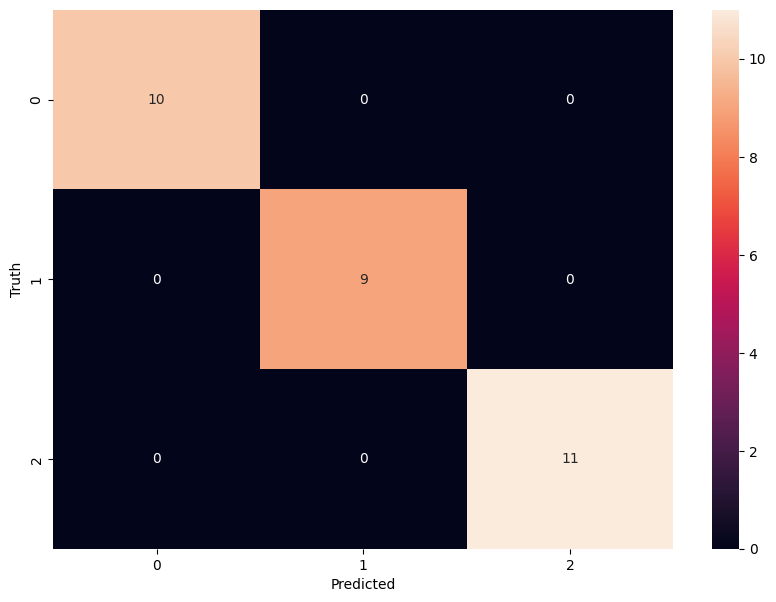

In [67]:
# Draw the confusion matrix using heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

#### Support Vector Regressor

In [82]:
tips = sns.load_dataset('tips')


In [83]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [84]:
# Encode the categorical variables
le = LabelEncoder()
tips['sex'] = le.fit_transform(tips['sex'])
tips['smoker'] = le.fit_transform(tips['smoker'])
tips['day'] = le.fit_transform(tips['day'])
tips['time'] = le.fit_transform(tips['time'])
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [89]:
# X and y
X = tips.drop('tip', axis=1)
y = tips['tip']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Call the model
model = SVR(kernel='linear')

# Train the model
model.fit(X_train, y_train)

# Predict the model
y_pred = model.predict(X_test)

In [91]:
model.predict([[16.99, 0, 0, 2, 0, 2]])

c:\Users\mypci\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


array([2.61992178])

In [93]:
# Evaluate the model
print(r2_score(y_test, y_pred))

0.45274050603842664
